# Demo: Markov chains and the Metropolis algorithm

**TIF285 — companion to the *MCMC sampling* chapter.**

Inverse-CDF sampling maps a uniform variate onto $p(x)$ in one shot, but it needs the
inverse distribution function $P^{-1}$. For a posterior
$p(\boldsymbol{\theta} \mid \mathcal{D}) \propto \mathcal{L}(\boldsymbol{\theta})\,p(\boldsymbol{\theta})$
we have neither $P^{-1}$ nor even the normalization. What we *can* do is evaluate the
unnormalized density at any point.

**The idea.** Give up on independent draws. Instead, construct a random *walk*
$\boldsymbol{\theta}_0 \to \boldsymbol{\theta}_1 \to \boldsymbol{\theta}_2 \to \dots$
whose long-run visit frequency equals $p(\boldsymbol{\theta})$. The plan:

1. **Markov chains** — the minimal theory: transition matrix, stationary and limiting distributions.
2. **Reverse the question** — the chain is not given, the target is. *Detailed balance* is the design tool.
3. **Metropolis** — the simplest transition rule that satisfies detailed balance, derived rather than postulated.
4. **What detailed balance does not promise** — burn-in, step size, autocorrelation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import logging
import emcee
logging.getLogger("emcee").setLevel(logging.ERROR)   # silence the too-short-chain warning; we discuss it below

INK, INK_SOFT, INK_MUTED, SURFACE = "#0b0b0b", "#52514e", "#8a8983", "#fcfcfb"
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"     # blue / orange / aqua
FILL1, FILL2 = "#cde2fb", "#fbdcd0"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 110,
    "axes.edgecolor": INK_MUTED, "axes.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "axes.labelcolor": INK, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "mathtext.fontset": "cm", "font.size": 11,
})

rng = np.random.default_rng(2026)

## 1. Markov chains in one page

A sequence of random variables $X_0, X_1, X_2, \dots$ is a **Markov chain** if the
next value depends on the present one only,

$$
\Pr(X_{n+1} = j \mid X_0 = i_0, \dots, X_n = i) = \Pr(X_{n+1} = j \mid X_n = i) \equiv T(i, j).
$$

We take the rule to be the same at every step (a *stationary* chain), so the whole
process is fixed by the starting distribution and the **transition matrix** $T$.
Its entry $T(i,j)$ is the probability of going *from* $i$ *to* $j$; every row is a
probability distribution, $T(i,j) \ge 0$ and $\sum_j T(i,j) = 1$ (a *stochastic matrix*).

Let $\pi_n$ be the row vector of state probabilities at step $n$. Marginalizing over
the previous state,

$$
\pi_{n+1}(j) = \sum_i \pi_n(i)\,T(i,j)
\quad\Longleftrightarrow\quad
\pi_{n+1} = \pi_n T,
\qquad\text{so}\qquad
\pi_n = \pi_0 T^{\,n}.
$$

Here is a three-state example. Think of it as a particle hopping between three sites.

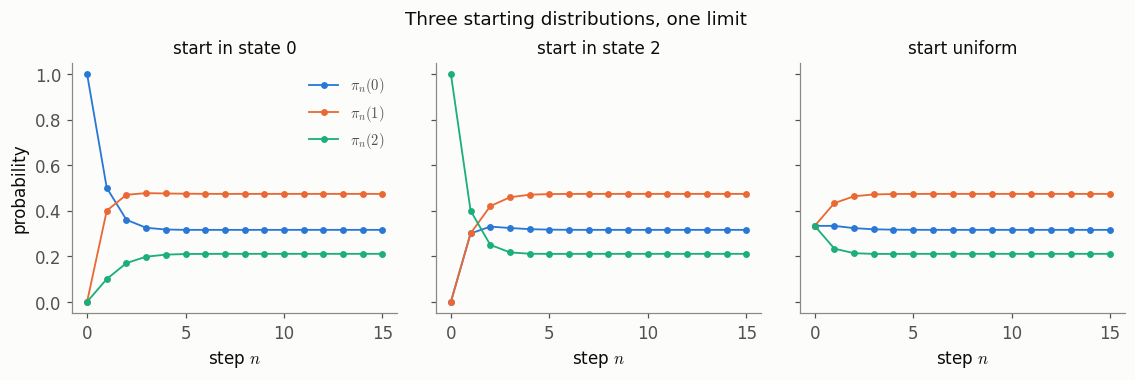

In [2]:
T = np.array([[0.5, 0.4, 0.1],
              [0.2, 0.6, 0.2],
              [0.3, 0.3, 0.4]])
assert np.allclose(T.sum(axis=1), 1.0)

def evolve(pi0, T, nsteps):
    "Return the array pi_0, pi_1, ..., pi_nsteps (row vectors)."
    out = [np.asarray(pi0, float)]
    for _ in range(nsteps):
        out.append(out[-1] @ T)
    return np.array(out)

starts = {"start in state 0": [1, 0, 0],
          "start in state 2": [0, 0, 1],
          "start uniform":    [1/3, 1/3, 1/3]}
NSTEPS = 15

fig, axes = plt.subplots(1, 3, figsize=(10.4, 3.4), sharey=True,
                         gridspec_kw=dict(wspace=0.12, left=0.06, right=0.98, top=0.84, bottom=0.17))
for ax, (label, pi0) in zip(axes, starts.items()):
    traj = evolve(pi0, T, NSTEPS)
    for k, col in enumerate([C1, C2, C3]):
        ax.plot(traj[:, k], "o-", ms=3.5, lw=1.2, color=col, label=fr"$\pi_n({k})$")
    ax.set_title(label, fontsize=11, pad=6)
    ax.set_xlabel("step $n$")
axes[0].set_ylabel("probability")
axes[0].legend(frameon=False, fontsize=9.5, labelcolor=INK_SOFT)
fig.suptitle("Three starting distributions, one limit", fontsize=12, y=0.98);

Whatever the start, $\pi_n$ settles on the same vector. That vector is the
**stationary distribution** $\pi^\ast$: it is unchanged by one more step,

$$
\pi^\ast = \pi^\ast T ,
$$

i.e. a left eigenvector of $T$ with eigenvalue $1$, normalized to $\sum_i \pi^\ast(i) = 1$.
When in addition $\pi_n \to \pi^\ast$ from *every* starting distribution, $\pi^\ast$ is also
the **limiting distribution**, and then the long-run fraction of time a single
realization spends in state $i$ is $\pi^\ast(i)$. That last statement is what lets us
use *one long chain* as a set of samples.

In [3]:
# stationary distribution from the eigenproblem  pi T = pi  <=>  T^T pi^T = pi^T
w, v = np.linalg.eig(T.T)
pi_star = np.real(v[:, np.argmin(np.abs(w - 1.0))])
pi_star /= pi_star.sum()
print("pi* from eigenvector :", pi_star.round(5))
print("pi_15 from iteration :", evolve([1, 0, 0], T, 15)[-1].round(5))
print("pi* T - pi*          :", (pi_star @ T - pi_star).round(12))

# one long realisation of the chain: visit frequencies -> pi*
def run_chain(T, i0, nsteps, rng):
    states = np.empty(nsteps + 1, int); states[0] = i0
    for n in range(nsteps):
        states[n + 1] = rng.choice(len(T), p=T[states[n]])
    return states

states = run_chain(T, 0, 20_000, rng)
print("visit frequencies    :", np.bincount(states, minlength=3).round(5) / len(states))

pi* from eigenvector : [0.31579 0.47368 0.21053]
pi_15 from iteration : [0.31579 0.47368 0.21053]
pi* T - pi*          : [-0. -0.  0.]
visit frequencies    : [0.3080346  0.47877606 0.21318934]


**When does the limit exist?** Two things can spoil it, and both are easy to picture.

* *Reducible* chain: some states cannot be reached from others (two disconnected
  islands). The limit then depends on where you start.
* *Periodic* chain: e.g. $T = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$ hops
  deterministically back and forth. $\pi^\ast = (\tfrac12, \tfrac12)$ is stationary, but
  $\pi_n$ alternates forever and never converges to it.

A finite chain that is irreducible and aperiodic has a unique stationary distribution
which is also its limiting distribution. We will design our chains so that both
conditions hold, and otherwise not worry about the theorem.

::::{admonition} Checkpoint
:class: my-checkpoint
The eigenvalue equation $\pi^\ast = \pi^\ast T$ has $\pi^\ast$ as the *unknown* and $T$ as
given. In MCMC it is the other way around: the target $p$ is given and we must find a $T$
that has it as stationary distribution. *Is that $T$ unique?*
::::

## 2. Reverse the question: detailed balance

We want a transition rule with $\pi^\ast = p$. The stationarity condition
$p(j) = \sum_i p(i)\,T(i,j)$ is global: it balances the total flow *into* $j$ against the
total flow *out of* $j$. A more restrictive but much easier condition is to balance
every pair of states separately,

$$
p(i)\,T(i,j) = p(j)\,T(j,i) \qquad \text{for all } i, j .
$$

This is **detailed balance**: the probability flow from $i$ to $j$ equals the flow from
$j$ to $i$. It implies stationarity in one line, by summing over $i$:

$$
\sum_i p(i)\,T(i,j) = \sum_i p(j)\,T(j,i) = p(j) \underbrace{\sum_i T(j,i)}_{=\,1} = p(j).
$$

Two remarks that carry the whole method.

* Rearranged, detailed balance reads $T(i,j)/T(j,i) = p(j)/p(i)$. Only the **ratio** of
  target probabilities enters. An unknown normalization constant cancels, which is exactly
  the situation for a posterior.
* Detailed balance is *sufficient*, not necessary. Many $T$ share the same $p$, so we are
  free to pick a convenient one (answer to the checkpoint: not unique).

For continuous variables the same equations hold with sums replaced by integrals and
$T(\boldsymbol{\theta}, \boldsymbol{\theta}')$ a transition *density*:

$$
p(\boldsymbol{\theta})\,T(\boldsymbol{\theta}, \boldsymbol{\theta}')
= p(\boldsymbol{\theta}')\,T(\boldsymbol{\theta}', \boldsymbol{\theta}),
\qquad
p(\boldsymbol{\theta}') = \int p(\boldsymbol{\theta})\,T(\boldsymbol{\theta}, \boldsymbol{\theta}')\,d\boldsymbol{\theta}.
$$

## 3. The Metropolis algorithm, derived

**Start with a chain that is easy to run but samples the wrong thing.** Let
$S(\boldsymbol{\theta}, \boldsymbol{\theta}')$ be a *proposal* density we can draw from,
for instance a Gaussian step centred on the current position,
$\boldsymbol{\theta}' \sim \mathcal{N}(\boldsymbol{\theta}, \sigma^2 I)$. Take it
**symmetric**, $S(\boldsymbol{\theta}, \boldsymbol{\theta}') = S(\boldsymbol{\theta}', \boldsymbol{\theta})$.
Used on its own, this random walk satisfies detailed balance with respect to a *flat*
density, not with respect to $p$.

**Repair it with an accept/reject step.** Propose $\boldsymbol{\theta}'$, then accept it
with probability $A(\boldsymbol{\theta}, \boldsymbol{\theta}')$; otherwise stay put. The
transition density for actually moving is

$$
T(\boldsymbol{\theta}, \boldsymbol{\theta}') = S(\boldsymbol{\theta}, \boldsymbol{\theta}')\,A(\boldsymbol{\theta}, \boldsymbol{\theta}')
\qquad (\boldsymbol{\theta}' \ne \boldsymbol{\theta}).
$$

(Staying put trivially satisfies detailed balance, so we need only consider moves.)
Insert into detailed balance and cancel the symmetric $S$:

$$
p(\boldsymbol{\theta})\,S\,A(\boldsymbol{\theta}, \boldsymbol{\theta}')
= p(\boldsymbol{\theta}')\,S\,A(\boldsymbol{\theta}', \boldsymbol{\theta})
\quad\Longrightarrow\quad
\frac{A(\boldsymbol{\theta}, \boldsymbol{\theta}')}{A(\boldsymbol{\theta}', \boldsymbol{\theta})}
= \frac{p(\boldsymbol{\theta}')}{p(\boldsymbol{\theta})} \equiv r .
$$

**Choose the largest acceptance that works.** Any $A$ with this ratio is valid; rejecting
needlessly only slows the chain, so we push one of the two probabilities to its maximum, $1$:

$$
A(\boldsymbol{\theta}, \boldsymbol{\theta}') = \min(1, r),
\qquad r = \frac{p(\boldsymbol{\theta}')}{p(\boldsymbol{\theta})}.
$$

*Check:* if $p(\boldsymbol{\theta}') \ge p(\boldsymbol{\theta})$ then $A(\boldsymbol{\theta},\boldsymbol{\theta}') = 1$
and $A(\boldsymbol{\theta}',\boldsymbol{\theta}) = p(\boldsymbol{\theta})/p(\boldsymbol{\theta}')$, so the ratio is
$p(\boldsymbol{\theta}')/p(\boldsymbol{\theta})$ as required; the opposite case is the mirror image.

**Reading the rule.** Uphill moves ($r \ge 1$) are always taken; downhill moves are taken
with probability $r$. The chain therefore *explores* rather than optimizes: it spends time
in a region in proportion to how probable that region is.

**Metropolis–Hastings.** If $S$ is not symmetric it does not cancel, and the same steps
give $r = \dfrac{p(\boldsymbol{\theta}')\,S(\boldsymbol{\theta}', \boldsymbol{\theta})}{p(\boldsymbol{\theta})\,S(\boldsymbol{\theta}, \boldsymbol{\theta}')}$.
Nothing else changes.

### The algorithm

Given $\boldsymbol{\theta}_n$:

1. Propose $\boldsymbol{\theta}' \sim S(\boldsymbol{\theta}_n, \cdot)$.
2. Compute $r = p(\boldsymbol{\theta}') / p(\boldsymbol{\theta}_n)$.
3. Draw $u \sim \mathcal{U}(0,1)$. If $u < r$ set $\boldsymbol{\theta}_{n+1} = \boldsymbol{\theta}'$, else $\boldsymbol{\theta}_{n+1} = \boldsymbol{\theta}_n$.

Step 3 accepts with probability $\min(1, r)$ in one line, since $u < r$ is certain when
$r \ge 1$. In code we work with $\ln p$ and compare $\ln u < \ln p(\boldsymbol{\theta}') - \ln p(\boldsymbol{\theta}_n)$
to avoid under/overflow. Note that a *rejected* proposal still adds a sample to the chain: the
current position is repeated.

### 3a. Discrete check: build $T$ for a given $\pi$

Before going continuous, run the construction on three states so that every object is a
matrix we can inspect. Target: $\pi = (\tfrac19, \tfrac34, \tfrac{5}{36})$. Proposal: from
state $i$, pick one of the *other two* states uniformly, $S(i,j) = \tfrac12$ for $j \ne i$.
The Metropolis transition matrix is $T(i,j) = S(i,j)\min(1, \pi_j/\pi_i)$ off the diagonal,
with the diagonal absorbing the rejected proposals so that rows sum to one.

In [4]:
pi_target = np.array([1/9, 3/4, 5/36])
n = len(pi_target)

S = (1 - np.eye(n)) / (n - 1)                                  # symmetric proposal
A = np.minimum(1.0, pi_target[None, :] / pi_target[:, None])   # A[i,j] = min(1, pi_j/pi_i)
T_metro = S * A
np.fill_diagonal(T_metro, 0.0)
np.fill_diagonal(T_metro, 1.0 - T_metro.sum(axis=1))          # rejections stay put

np.set_printoptions(precision=4, suppress=True)
print("T =\n", T_metro)
print("rows sum to one     :", np.allclose(T_metro.sum(axis=1), 1))
print("detailed balance    :", np.allclose(pi_target[:, None] * T_metro, (pi_target[:, None] * T_metro).T))
print("pi T = pi           :", np.allclose(pi_target @ T_metro, pi_target))
print("limit from state 0  :", evolve([1, 0, 0], T_metro, 60)[-1])

T =
 [[0.     0.5    0.5   ]
 [0.0741 0.8333 0.0926]
 [0.4    0.5    0.1   ]]
rows sum to one     : True
detailed balance    : True
pi T = pi           : True
limit from state 0  : [0.1111 0.75   0.1389]


The chain was built from $\pi$ *ratios* only, yet it has $\pi$ as its limit. This is the
whole of MCMC; what follows is the same construction on a continuum of states.

### 3b. Continuous: a random-walk Metropolis sampler in ten lines

In [5]:
def metropolis(log_p, theta0, step, nsteps, rng):
    '''Random-walk Metropolis with an isotropic Gaussian proposal of width `step`.

    Returns the chain (nsteps+1, ndim) and the acceptance fraction.
    `log_p` may be unnormalized: only differences are used.
    '''
    theta = np.atleast_1d(np.asarray(theta0, float))
    lp = log_p(theta)
    chain = np.empty((nsteps + 1, theta.size)); chain[0] = theta
    accepted = 0
    for n in range(1, nsteps + 1):
        proposal = theta + step * rng.standard_normal(theta.size)   # S: symmetric
        lp_prop = log_p(proposal)
        if np.log(rng.uniform()) < lp_prop - lp:                    # accept w.p. min(1, r)
            theta, lp = proposal, lp_prop
            accepted += 1
        chain[n] = theta                                            # repeated if rejected
    return chain, accepted / nsteps

Target: an *unnormalized* two-component mixture on the line,

$$
\tilde p(x) = e^{-(x+2)^2/2} + \tfrac{1}{2}\,e^{-(x-3)^2/(2\cdot 0.6^2)} .
$$

We never compute its normalization; the sampler does not need it. For the plots we
normalize numerically on a grid, purely so that the histogram can be compared to a curve.

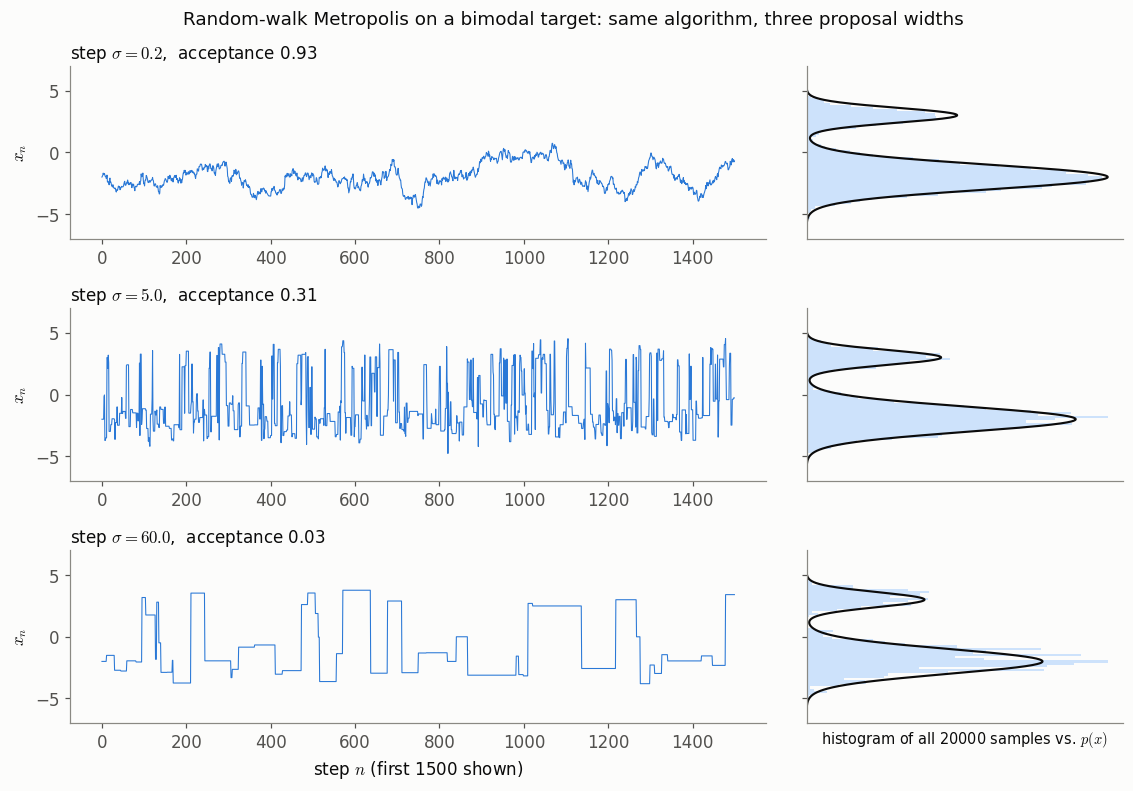

In [6]:
def log_p_bimodal(x):
    x = x[0]
    return np.logaddexp(-0.5 * (x + 2.0)**2,
                        np.log(0.5) - 0.5 * ((x - 3.0) / 0.6)**2)

xg = np.linspace(-7, 7, 1400)
p_grid = np.exp([log_p_bimodal(np.array([x])) for x in xg])
p_grid /= np.trapezoid(p_grid, xg)          # for plotting only

NSTEPS = 20_000
steps = [0.2, 5.0, 60.0]
runs = {s: metropolis(log_p_bimodal, [-2.0], s, NSTEPS, np.random.default_rng(1)) for s in steps}

fig, axes = plt.subplots(3, 2, figsize=(10.4, 7.2), width_ratios=[2.2, 1],
                         gridspec_kw=dict(wspace=0.08, hspace=0.4, left=0.06, right=0.98, top=0.91, bottom=0.08))
for row, s in enumerate(steps):
    chain, acc = runs[s]
    ax_tr, ax_h = axes[row]
    ax_tr.plot(chain[:1500, 0], lw=0.7, color=C1)
    ax_tr.set_ylim(-7, 7); ax_tr.set_ylabel("$x_n$")
    ax_tr.set_title(fr"step $\sigma={s}$,  acceptance {acc:.2f}", fontsize=11, loc="left", pad=5)
    ax_h.hist(chain[:, 0], bins=80, range=(-7, 7), density=True, orientation="horizontal",
              color=FILL1, edgecolor="none")
    ax_h.plot(p_grid, xg, color=INK, lw=1.4)
    ax_h.set_ylim(-7, 7); ax_h.set_yticklabels([]); ax_h.set_xticks([])
axes[-1, 0].set_xlabel("step $n$ (first 1500 shown)")
axes[-1, 1].set_xlabel(f"histogram of all {NSTEPS} samples vs. $p(x)$", fontsize=9.5)
fig.suptitle("Random-walk Metropolis on a bimodal target: same algorithm, three proposal widths", fontsize=12);

All three chains are *correct* in the sense that detailed balance holds and the limiting
distribution is $p$. They are not equally *useful*:

* $\sigma = 0.2$: nearly every proposal is accepted, but the walker crawls. In the 1500
  steps shown it never leaves the first mode; over the full run it crosses the gap only a
  handful of times, so the relative weight of the two modes in the histogram rests on
  those few crossings and would change noticeably with another seed.
* $\sigma = 5$: comparable to the distance between the modes. About a third of the
  proposals are accepted and the chain hops between the modes every few steps.
* $\sigma = 60$: almost every proposal lands far out in the tails where $p \approx 0$ and
  is rejected; the trace is a staircase of long flat stretches. The histogram is still
  roughly right, because the rare accepted jumps land anywhere, but the chain is worth
  far fewer samples than its length.

::::{admonition} Checkpoint
:class: my-checkpoint
A high acceptance rate looks like success. *Why is it a warning sign for a random-walk
sampler?* And why is the flat-line behaviour at large $\sigma$ not a bug in the code but a
requirement of detailed balance?
::::

### 3c. Two dimensions: the walk as a picture

A correlated Gaussian, so that we can draw the trajectory on top of the density.
Accepted moves are drawn as line segments; rejected proposals as faint dots.

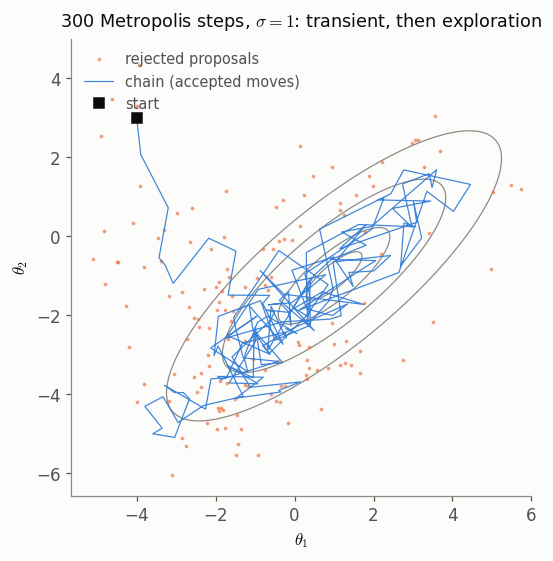

In [7]:
MU2 = np.array([1.0, -1.0])
COV2 = np.array([[2.0, 1.4], [1.4, 1.5]])
COV2_INV = np.linalg.inv(COV2)

def log_p_gauss2(theta):
    d = theta - MU2
    return -0.5 * d @ COV2_INV @ d          # unnormalized

def metropolis_verbose(log_p, theta0, step, nsteps, rng):
    "As `metropolis`, but also returns the rejected proposals (for plotting)."
    theta = np.asarray(theta0, float); lp = log_p(theta)
    chain, rejected = [theta.copy()], []
    for _ in range(nsteps):
        prop = theta + step * rng.standard_normal(theta.size)
        lp_prop = log_p(prop)
        if np.log(rng.uniform()) < lp_prop - lp:
            theta, lp = prop, lp_prop
        else:
            rejected.append(prop)
        chain.append(theta.copy())
    return np.array(chain), np.array(rejected)

chain2, rejected2 = metropolis_verbose(log_p_gauss2, [-4.0, 3.0], 1.0, 300, np.random.default_rng(7))

g1, g2 = np.meshgrid(np.linspace(-5, 6, 200), np.linspace(-5, 5, 200))
Z = np.exp([[log_p_gauss2(np.array([a, b])) for a in g1[0]] for b in g2[:, 0]])

fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.contour(g1, g2, Z, levels=np.exp(-0.5 * np.array([9, 4, 1, 0.25])), colors=INK_MUTED, linewidths=0.8)
ax.plot(rejected2[:, 0], rejected2[:, 1], ".", ms=3, color=C2, alpha=0.5, label="rejected proposals")
ax.plot(chain2[:, 0], chain2[:, 1], "-", lw=0.8, color=C1, alpha=0.9, label="chain (accepted moves)")
ax.plot(*chain2[0], "s", ms=7, color=INK, label="start")
ax.set_xlabel(r"$\theta_1$"); ax.set_ylabel(r"$\theta_2$"); ax.set_aspect("equal")
ax.legend(frameon=False, fontsize=9.5, labelcolor=INK_SOFT, loc="upper left")
ax.set_title("300 Metropolis steps, $\sigma = 1$: transient, then exploration", fontsize=11.5, pad=8);

Two features to point at. The first few dozen steps are a nearly deterministic march
from the start towards the high-probability region; that stretch is not representative of
$p$ and is what we discard as **burn-in**. And the isotropic proposal is a poor match to
an elongated target: steps along the short axis are rejected, steps along the long axis are
tiny compared to the extent of the distribution. This is the mismatch that made the
random-walk move struggle in problem set 1, and it is the motivation for proposals that
adapt to the target shape (ensemble samplers, Hamiltonian Monte Carlo).

## 4. What detailed balance does not promise

Detailed balance guarantees the *destination*: the limiting distribution is $p$. It says
nothing about *how fast* the chain gets there or how fast it moves around once it has
arrived. Two quantities capture this, and both were measured in problem set 1.

**Burn-in.** The distance in steps from the starting point to the region where
$\pi_n \approx p$. Discarded.

**Autocorrelation time.** Consecutive samples are correlated because each is a small
modification of the last. The normalized autocorrelation function of a scalar $f(\boldsymbol{\theta}_n)$,

$$
\rho(k) = \frac{\mathrm{Cov}[f_n, f_{n+k}]}{\mathrm{Var}[f_n]},
\qquad
\tau = 1 + 2\sum_{k=1}^{\infty} \rho(k),
$$

defines the **integrated autocorrelation time** $\tau$: roughly the number of steps until
the chain has forgotten where it was. A chain of $N$ samples is then worth
$N_\mathrm{eff} = N/\tau$ independent draws, and every estimate carries a Monte Carlo
error $\propto 1/\sqrt{N_\mathrm{eff}}$, not $1/\sqrt{N}$.

  step   accept      tau    N_eff
   0.2     0.93    699.6       26
   5.0     0.31      7.5     2411
  60.0     0.03     61.8      291


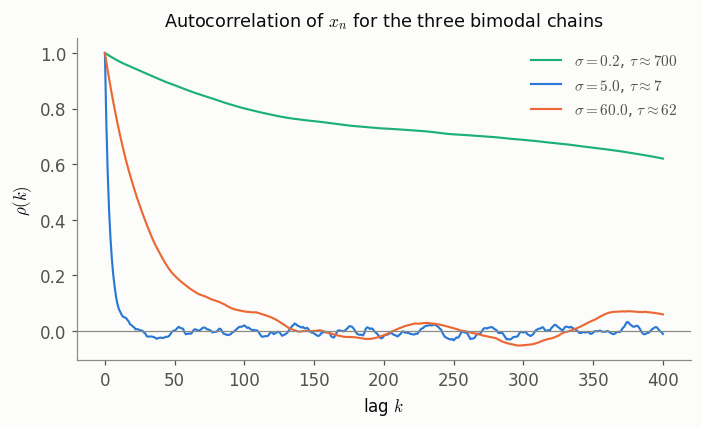

In [8]:
def autocorr(x, kmax):
    "Normalized autocorrelation rho(k), k = 0..kmax, by direct estimate."
    x = x - x.mean()
    var = np.dot(x, x) / len(x)
    return np.array([np.dot(x[:len(x)-k], x[k:]) / len(x) / var for k in range(kmax + 1)])

KMAX = 400
fig, ax = plt.subplots(figsize=(7.2, 3.8))
print(f"{'step':>6} {'accept':>8} {'tau':>8} {'N_eff':>8}")
for s, col in zip(steps, [C3, C1, C2]):
    chain, acc = runs[s]
    x = chain[2000:, 0]                                    # discard burn-in
    tau = emcee.autocorr.integrated_time(x, quiet=True)[0]
    print(f"{s:6.1f} {acc:8.2f} {tau:8.1f} {len(x)/tau:8.0f}")
    ax.plot(autocorr(x, KMAX), lw=1.4, color=col, label=fr"$\sigma={s}$, $\tau\approx{tau:.0f}$")
ax.axhline(0, color=INK_MUTED, lw=0.8)
ax.set_xlabel("lag $k$"); ax.set_ylabel(r"$\rho(k)$")
ax.legend(frameon=False, fontsize=10, labelcolor=INK_SOFT)
ax.set_title("Autocorrelation of $x_n$ for the three bimodal chains", fontsize=11.5, pad=8);

The same 20,000 samples are worth a few thousand independent draws with a well-chosen step
and far fewer with a poorly chosen one. Detailed balance was satisfied in every case.
For $\sigma = 0.2$ the $\tau$ estimate is itself unreliable: the chain is not even 50
autocorrelation times long, which is the `AutocorrError` you met in problem set 1. A
$\tau$ estimated from a chain that has not yet explored the target is biased *low*, so the
true value is worse than the number printed.

### 4a. Where $N_\mathrm{eff} = N/\tau$ comes from

The effective sample size is defined through the variance of a *sum*. Let $f_1, \dots, f_N$
be samples from a stationary chain with $\mathrm{Var}[f_n] = \sigma_0^2$ and
$\mathrm{Cov}[f_i, f_j] = \sigma_0^2\,\rho(|i-j|)$, and let $z = \frac1N \sum_n f_n$ be the
chain estimate of the mean. Expanding the square and counting pairs at each lag $k$
(there are $N-k$ of them, twice),

$$
\mathrm{Var}[z] = \frac{\sigma_0^2}{N^2}\sum_{i,j}\rho(|i-j|)
= \frac{\sigma_0^2}{N}\Bigl[\,1 + 2\sum_{k=1}^{N-1}\Bigl(1-\frac{k}{N}\Bigr)\rho(k)\Bigr]
\equiv \frac{\sigma_0^2}{N_\mathrm{eff}} .
$$

The last equality *defines* $N_\mathrm{eff}$: the number of independent samples that would
give the same Monte Carlo error. Everything depends on what $\rho(k)$ does.

* **Constant correlation, $\rho(k) = \rho$ for all $k$** (the example in the *Expectation
  values and moments* section of the book). The sum gives $\rho\,(N-1)/2$, so
  $N_\mathrm{eff} = N / [1 + (N-1)\rho]$, which *saturates* at $1/\rho$ as $N \to \infty$.
  This is the model $f_n = \mu + a + \epsilon_n$ with a shared random offset $a$: more samples
  never average $a$ away. It shows that correlation destroys information, but it is not how a
  chain behaves.

* **Decaying correlation, $\sum_k |\rho(k)| < \infty$** (any irreducible, aperiodic Markov
  chain). For $N$ much longer than the correlation length the factor $(1-k/N) \to 1$ and the
  bracket tends to a constant,

  $$
  \tau = 1 + 2\sum_{k=1}^{\infty}\rho(k), \qquad N_\mathrm{eff} \to \frac{N}{\tau},
  $$

  which grows linearly with $N$. The decay does not have to be exponential for this to hold,
  only summable; the exponential is what a finite Markov chain actually delivers.

**Why exponential for a Markov chain.** Write the transition matrix in its eigenbasis. For
any function $f$ of the state, the lag-$k$ covariance is a combination of $\lambda_m^k$ over
the eigenvalues $\lambda_m \ne 1$ of $T$, so $|\rho(k)| \le C\,|\lambda_2|^k$ with $\lambda_2$
the second-largest eigenvalue in magnitude. If a single mode dominates, $\rho(k) = \lambda^k$
and the geometric series gives the tidy result

$$
\tau = 1 + \frac{2\lambda}{1-\lambda} = \frac{1+\lambda}{1-\lambda}.
$$

::::{admonition} Summary
:class: my-checkpoint
* A Markov chain is fixed by its transition rule $T$; an irreducible, aperiodic chain has a
  unique limiting distribution $\pi^\ast = \pi^\ast T$, and a single long run visits states with
  frequency $\pi^\ast$.
* MCMC inverts the problem: choose $T$ so that $\pi^\ast = p$. **Detailed balance**
  $p(\boldsymbol{\theta})T(\boldsymbol{\theta},\boldsymbol{\theta}') = p(\boldsymbol{\theta}')T(\boldsymbol{\theta}',\boldsymbol{\theta})$ is a
  sufficient condition, and it involves only ratios of $p$, so normalization is irrelevant.
* **Metropolis**: a symmetric proposal plus acceptance $\min(1, p(\boldsymbol{\theta}')/p(\boldsymbol{\theta}))$
  is the simplest $T$ that satisfies it.
* Correctness is guaranteed; efficiency is not. Burn-in and the autocorrelation time $\tau$
  measure the cost, and the proposal's shape and width are what control it.
::::